In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from pathlib import Path

blog_visuals = Path("visuals")
blog_visuals.mkdir(parents=True, exist_ok=True)

FIG_SIZE = (8.8, 5.6)
EXPORT_DPI = 220
THUMBNAIL_SIZE = (11, 6.3)
THUMBNAIL_DPI = 100

plt.rcParams.update({"axes.titlesize": 14, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 11,})

In [ ]:
# Taken from Expected Shots project output
quantity_n = 11.9284
quantity_p = 0.4901
quality_mean = 0.0509
quality_sigma = 1.0137
quality_mu = np.log(quality_mean)

attack_quantity_mult = 1.13
attack_quality_mult_winner = 1.16
lead_now = 1

rng = np.random.default_rng(7)

In [69]:
def strategy_multipliers(strategy, X=0.0, Y=0.0):
    if strategy == "attack":
        return attack_quantity_mult, attack_quality_mult_winner, attack_quantity_mult, 1.0
    if strategy == "park":
        return attack_quantity_mult*(1.0-X), 1.0, attack_quantity_mult*(1.0+X), 1.0-Y
    return 1.0, 1.0, 1.0, 1.0


def sample_team_goal_events(minutes_left, sims, quantity_mult, quality_mult):
    latent_shots_per90 = rng.gamma(shape=quantity_n, scale=(1.0-quantity_p)/quantity_p, size=sims)
    expected_shots = latent_shots_per90 * quantity_mult * (minutes_left / 90.0)
    shot_counts = rng.poisson(expected_shots)
    total_shots = int(shot_counts.sum())

    if total_shots == 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    sim_ids = np.repeat(np.arange(sims), shot_counts)
    shot_xg = np.clip(rng.lognormal(mean=quality_mu, sigma=quality_sigma, size=total_shots) * quality_mult, 0.0, 1.0)
    is_goal = rng.random(total_shots) < shot_xg

    if not is_goal.any():
        return np.array([], dtype=int), np.array([], dtype=float)

    goal_sim_ids = sim_ids[is_goal]
    goal_times = rng.random(len(goal_sim_ids)) * minutes_left
    return goal_sim_ids, goal_times


def simulate_terminal_outcomes(minutes_left, strategy, sims, lead_start=1, X=0.0, Y=0.0):
    q_E, s_E, q_A, s_A = strategy_multipliers(strategy, X=X, Y=Y)
    eng_ids, eng_times = sample_team_goal_events(minutes_left, sims, q_E, s_E)
    arg_ids, arg_times = sample_team_goal_events(minutes_left, sims, q_A, s_A)

    terminal = np.ones(sims, dtype=float)

    if len(eng_ids) + len(arg_ids) == 0:
        return terminal

    event_ids = np.concatenate([eng_ids, arg_ids])
    event_times = np.concatenate([eng_times, arg_times])
    event_delta = np.concatenate([np.ones(len(eng_ids), dtype=int), -np.ones(len(arg_ids), dtype=int)])

    order = np.lexsort((event_times, event_ids))
    event_ids = event_ids[order]
    event_delta = event_delta[order]

    lead = np.full(sims, int(lead_start), dtype=int)
    active = np.ones(sims, dtype=bool)

    for sim_id, delta in zip(event_ids, event_delta):
        if not active[sim_id]:
            continue

        lead[sim_id] += delta
        if lead[sim_id] <= 0:
            terminal[sim_id] = 0.5
            active[sim_id] = False

    return terminal


def total_win_prob(minutes_left, strategy, sims, lead_start=1, X=0.0, Y=0.0):
    return simulate_terminal_outcomes(minutes_left, strategy, sims, lead_start, X, Y).mean()


def outcome_probs_if_leading(lead_now, minutes_left, strategy, sims=5000, X=0.0, Y=0.0):
    terminal = simulate_terminal_outcomes(minutes_left, strategy, sims, lead_now, X, Y)
    outright = np.mean(terminal == 1.0)
    coinflip = np.mean(terminal == 0.5)
    expected_win = terminal.mean()
    return outright, coinflip, expected_win


def break_even_Y(minutes_left, X, Y_grid, sims):
    attack_val = total_win_prob(minutes_left, "attack", sims=sims, lead_start=lead_now)
    deltas = np.array(
        [
            total_win_prob(minutes_left, "park", sims=sims, lead_start=lead_now, X=X, Y=Y) - attack_val
            for Y in Y_grid
        ]
    )

    exact = np.where(np.isclose(deltas, 0.0, atol=1e-4))[0]
    if len(exact) > 0:
        return float(Y_grid[exact[0]])

    sign = np.sign(deltas)
    change = np.where(sign[:-1] * sign[1:] < 0)[0]
    if len(change) == 0:
        return np.nan

    i = int(change[0])
    x1, x2 = Y_grid[i], Y_grid[i + 1]
    y1, y2 = deltas[i], deltas[i + 1]
    return float(x1 - y1 * (x2 - x1) / (y2 - y1))

In [78]:
minutes_grid = np.arange(0, 91, 5)
X_fixed = 0.25
Y_lines = [0.20, 0.30, 0.40]
TIME_STORY_SIMS = 500_000

attack_by_minute = {
    minutes_left: total_win_prob(minutes_left, "attack", sims=TIME_STORY_SIMS, lead_start=lead_now)
    for minutes_left in minutes_grid
}

rows = []
for Y in Y_lines:
    for minutes_left in minutes_grid:
        park_total = total_win_prob(minutes_left, "park", sims=TIME_STORY_SIMS, lead_start=lead_now, X=X_fixed, Y=Y)
        rows.append(
            {
                "minutes_left": minutes_left,
                "X": X_fixed,
                "Y": Y,
                "attack_win_prob": attack_by_minute[minutes_left],
                "park_win_prob": park_total,
                "parking_advantage_pp": 100.0 * (park_total - attack_by_minute[minutes_left]),
            }
        )

time_story = pd.DataFrame(rows)

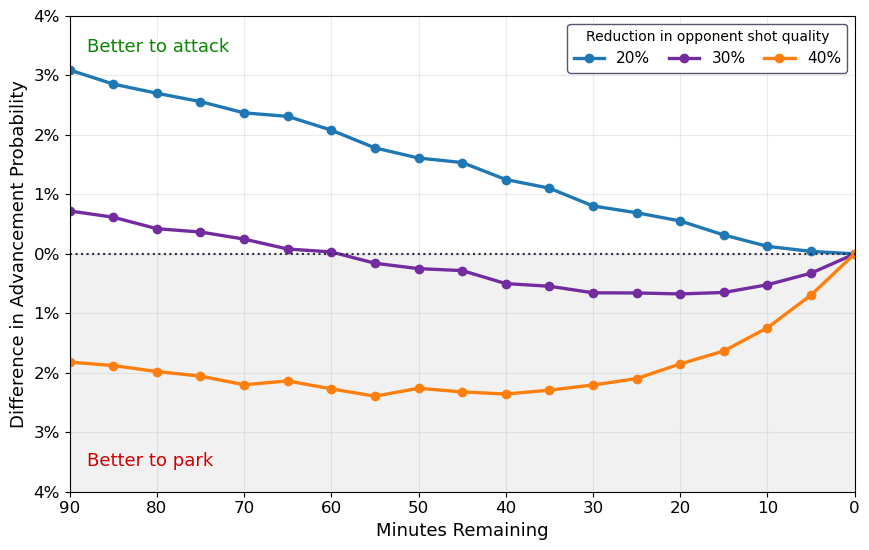

In [99]:
fig_main, ax_main = plt.subplots(figsize=FIG_SIZE)
time_story_plot = time_story.copy()
time_story_plot["attack_advantage_pp"] = -time_story_plot["parking_advantage_pp"]

line_colors = ["#1f77b4", "#732ca0", "#ff7f0e"]
for Y, color in zip(Y_lines, line_colors):
    g = time_story_plot[time_story_plot["Y"] == Y].sort_values("minutes_left")
    ax_main.plot(
        g["minutes_left"],
        g["attack_advantage_pp"],
        marker="o",
        linewidth=2.4,
        color=color,
        label=f"{int(100 * Y)}%",
    )

ax_main.axhline(0, color="#2b2d42", linewidth=1.5, linestyle=":")
ax_main.set_xlim(90, 0)
ax_main.set_xticks(np.arange(0, 91, 10))

y_extent = np.nanmax(np.abs(time_story_plot["attack_advantage_pp"]))
y_lim = np.ceil(y_extent)
ax_main.set_ylim(-y_lim, y_lim)
ax_main.axhspan(-y_lim, 0, color="lightgray", alpha=0.3, zorder=0)

ax_main.text(88, 0.87 * y_lim, "Better to attack", ha="left", va="center", fontsize=13, color="#0b8601")
ax_main.text(88, -0.87 * y_lim, "Better to park", ha="left", va="center", fontsize=13, color="#d00100")

yticks = np.arange(-y_lim, y_lim + 1, 1)
ax_main.set_yticks(yticks)
ax_main.set_yticklabels([f"{abs(int(t))}%" for t in yticks])

ax_main.set_xlabel("Minutes Remaining")
ax_main.set_ylabel("Difference in Advancement Probability")
ax_main.legend(
    frameon=True,
    fancybox=True,
    framealpha=0.95,
    edgecolor="#4a4e69",
    facecolor="white",
    ncol=3,
    title="Reduction in opponent shot quality",
    loc="upper right",
    columnspacing=1.2,
    handlelength=2.0,
)
ax_main.grid(alpha=0.25)
fig_main.tight_layout()
plt.show()

In [72]:
minutes_fixed = 35
X_grid = np.arange(0.00, 0.501, 0.025)
Y_grid = np.arange(0.00, 0.501, 0.025)
MAP_SIMS = 250_000

attack_fixed = total_win_prob(minutes_fixed, "attack", sims=MAP_SIMS, lead_start=lead_now)

adv_grid = np.zeros((len(Y_grid), len(X_grid)))
for yi, Y in enumerate(Y_grid):
    for xi, X in enumerate(X_grid):
        park_total = total_win_prob(minutes_fixed, "park", sims=MAP_SIMS, lead_start=lead_now, X=X, Y=Y)
        adv_grid[yi, xi] = 100.0 * (park_total - attack_fixed)

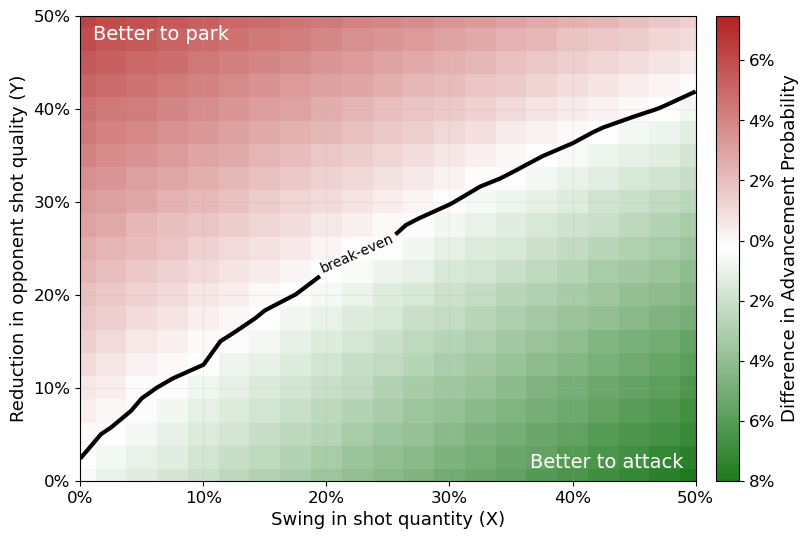

In [98]:
X_mesh, Y_mesh = np.meshgrid(X_grid, Y_grid)

abs_lim = float(np.nanmax(np.abs(adv_grid)))
if abs_lim == 0.0:
    abs_lim = 1.0

norm = mcolors.TwoSlopeNorm(vmin=-abs_lim, vcenter=0.0, vmax=abs_lim)
cmap_rg = mcolors.LinearSegmentedColormap.from_list("park_attack", ["#1f7a1f", "#ffffff", "#b22222"])

fig_be, ax_be = plt.subplots(figsize=FIG_SIZE)
pcm = ax_be.pcolormesh(X_mesh, Y_mesh, adv_grid, shading="auto", cmap=cmap_rg, norm=norm)
contours = ax_be.contour(X_mesh, Y_mesh, adv_grid, levels=[0.0], colors="black", linewidths=3)
ax_be.clabel(contours, fmt={0.0: "break-even"}, inline=True, fontsize=10)

cbar = fig_be.colorbar(pcm, ax=ax_be, location="right", fraction=0.05, pad=0.03)
cbar.set_label("Difference in Advancement Probability")
cb_ticks = np.arange(-abs_lim, abs_lim + 0.001, 2.0)
if len(cb_ticks) < 2:
    cb_ticks = np.array([-abs_lim, 0.0, abs_lim])
cbar.set_ticks(cb_ticks)
cbar.set_ticklabels([f"{abs(int(round(t)))}%" for t in cb_ticks])

ax_be.set_xlim(0, 0.5)
ax_be.set_ylim(0, 0.5)
tick_vals = np.arange(0.0, 0.51, 0.1)
ax_be.set_xticks(tick_vals)
ax_be.set_yticks(tick_vals)
ax_be.set_xticklabels([f"{int(100*t)}%" for t in tick_vals])
ax_be.set_yticklabels([f"{int(100*t)}%" for t in tick_vals])

ax_be.set_xlabel("Swing in shot quantity (X)")
ax_be.set_ylabel("Reduction in opponent shot quality (Y)")
ax_be.text(0.01, 0.49, "Better to park", ha="left", va="top", fontsize=14, color="white")
ax_be.text(0.49, 0.01, "Better to attack", ha="right", va="bottom", fontsize=14, color="white")
ax_be.grid(alpha=0.18)
fig_be.subplots_adjust(left=0.12, right=0.88, bottom=0.12, top=0.95)
plt.show()

tuchel_map = pd.DataFrame(
    {
        "minutes_left": minutes_fixed,
        "X": np.repeat(X_grid, len(Y_grid)),
        "Y": np.tile(Y_grid, len(X_grid)),
        "parking_advantage_pp": adv_grid.T.reshape(-1),
    }
)

In [100]:
main_plot_path = blog_visuals / "bus-parking-time-story.png"
fig_main.savefig(main_plot_path, dpi=EXPORT_DPI)

tuchel_plot_path = blog_visuals / "bus-parking-tuchel-map.png"
fig_be.savefig(tuchel_plot_path, dpi=EXPORT_DPI)

thumb_path = blog_visuals / "thumbnail-bus-parking.png"
original_size = fig_be.get_size_inches().copy()
fig_be.set_size_inches(*THUMBNAIL_SIZE)
fig_be.savefig(thumb_path, dpi=THUMBNAIL_DPI)
fig_be.set_size_inches(*original_size)